# 12. Capacity Expansion I — Single Technology (Solar PV)

Every model so far has treated `p_nom` as a fixed input: the analyst decides how big each asset is,
and the solver only decides how to *operate* it. This model introduces the opposite question — given
a fixed wind fleet, a load to serve, and a grid connection, **how big should the solar plant be?**

The objective is to model a system with a fixed 15 MW wind plant, a fixed industrial load, and a
two-directional grid connection, but with the solar PV plant's capacity left as a free variable for
the solver to choose. This requires two new ingredients: `p_nom_extendable=True` (telling PyPSA that
`p_nom` is now a decision variable instead of a fixed input) and `capital_cost` (an annualized cost
per MW of capacity, so that building more solar isn't free).

## Why the solver needs a capital cost to make this decision
Without a capital cost, there's no reason *not* to build infinite solar capacity — more free-marginal-
cost generation can never hurt the objective. `capital_cost` is what makes bigger less obviously
better: every additional MW of solar adds a fixed annual cost regardless of how much it actually
generates, so the solver has to weigh that cost against the value of the electricity it displaces
(avoided grid import) or sells (grid export revenue). The optimal capacity is the point where one
more MW of solar would cost more (in annualized capital) than it's worth (in avoided import cost and
export revenue).

## System Topology
1. **Bus:** a single electrical bus.
2. **Generators (Source):** `Solar_PV` — now `p_nom_extendable=True`, with an annualized
   `capital_cost` and a capacity limit (`p_nom_max`) representing the maximum installable capacity at
   the site. `Wind` remains fixed at 15 MW, as in earlier models.
3. **Generators (Grid, two-directional):** `Grid_Import` and `Grid_Export`, unchanged from earlier
   models.
4. **Loads:** the same day/night industrial load used since Model 03.


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../')
from utils.viz_utils import set_nature_style
set_nature_style()

df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## Technical Parameters

`capital_cost` in PyPSA is expected in currency per MW **per snapshot-weighted year** — in practice,
an annualized figure. It's calculated here with a standard Capital Recovery Factor (CRF), converting
an overnight investment cost and a project lifetime into an equivalent annual payment, plus a fixed
O&M percentage on top. `p_nom_max` caps how much capacity the solver is allowed to build, representing
a physical site-area constraint.


In [2]:
DISCOUNT_RATE = 0.04

def annuity(lifetime_years, investment, fom_percent):
    r = DISCOUNT_RATE
    crf = (r * (1 + r) ** lifetime_years) / ((1 + r) ** lifetime_years - 1)
    return investment * (crf + fom_percent / 100.0)

tech_param = {
    'solar_pv': {
        'p_nom_max': 30.0,                          # Maximum installable capacity, MW (site limit)
        'capital_cost': annuity(30, 550_000, 2.0),   # EUR/MW/year
        'marginal_cost': 0.0
    },
    'wind': {
        'p_nom': 15.0,      # Fixed, unlike solar
        'marginal_cost': 0.0
    },
    'market_grid': {
        'import_p_nom': 20.0,
        'export_p_nom': 18.0
    },
    'demand': {
        'day_load_mw': 8.0,
        'night_load_mw': 4.0
    }
}

print(f"Solar PV annualized capital cost: EUR {tech_param['solar_pv']['capital_cost']:,.0f} / MW / year")


Solar PV annualized capital cost: EUR 42,807 / MW / year


## Initializing the Network

A single electrical bus, as in earlier models.


In [3]:
n = pypsa.Network()
n.set_snapshots(df_pv.index)
n.add("Bus", "electricity_bus")


Index(['electricity_bus'], dtype='object')

## Adding Generators and the Grid Connection

`Solar_PV` is the only new mechanic here: `p_nom_extendable=True` makes its capacity a decision
variable, `p_nom_max` bounds how large it's allowed to grow, and `capital_cost` prices every MW it
does build. `Wind`, `Grid_Import`, and `Grid_Export` are added exactly as in earlier models, all with
fixed capacities.


In [4]:
n.add("Generator", "Solar_PV", bus="electricity_bus",
      p_nom_extendable=True,
      p_nom_max=tech_param['solar_pv']['p_nom_max'],
      p_max_pu=df_pv['capacity_factor'],
      capital_cost=tech_param['solar_pv']['capital_cost'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

n.add("Generator", "Wind", bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'],
      p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

n.add("Generator", "Grid_Import", bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'],
      marginal_cost=df_price['price'])

n.add("Generator", "Grid_Export", bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0, p_max_pu=0.0,
      marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## Adding the Electrical Demand

The same day/night industrial load used since Model 03.


In [5]:
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
load_profile = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
load_profile = pd.Series(load_profile, index=n.snapshots)

n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=load_profile)


Index(['Industrial_Load'], dtype='object')

## Running the Optimization

With `Solar_PV` extendable, the solver now solves a combined **investment and dispatch** problem in
one pass: it chooses a capacity, then dispatches every hour of the year against that capacity,
jointly minimizing annualized capital cost plus operating cost net of grid revenue.


In [6]:
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Annualized Capital + Net Operating Cost): EUR {n.objective:,.2f}")


Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 18.57it/s]
INFO:linopy.io: Writing time: 0.62s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35041 primals, 78842 duals
Objective: -1.22e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


Solver Status: ok
Total Objective Value (Annualized Capital + Net Operating Cost): EUR -1,217,895.42


## Analyzing the Results

The key new number here is `n.generators.at['Solar_PV', 'p_nom_opt']` — the capacity the solver
actually chose, as opposed to `p_nom_max`, the upper limit it was allowed to consider. Comparing the
two shows whether the site constraint was binding (the solver would have built more if it could) or
whether the solver found an interior optimum below the site limit.


Optimal Solar PV Capacity:      30.00 MW  (site limit: 30.0 MW)
Solar Annualized CAPEX:         EUR 1,284,196.64 / year
---------------------------------------------
Solar Production:               28,856.32 MWh
Wind Production:                57,564.60 MWh
Grid Import:                    8,186.35 MWh
Grid Export:                    44,967.27 MWh


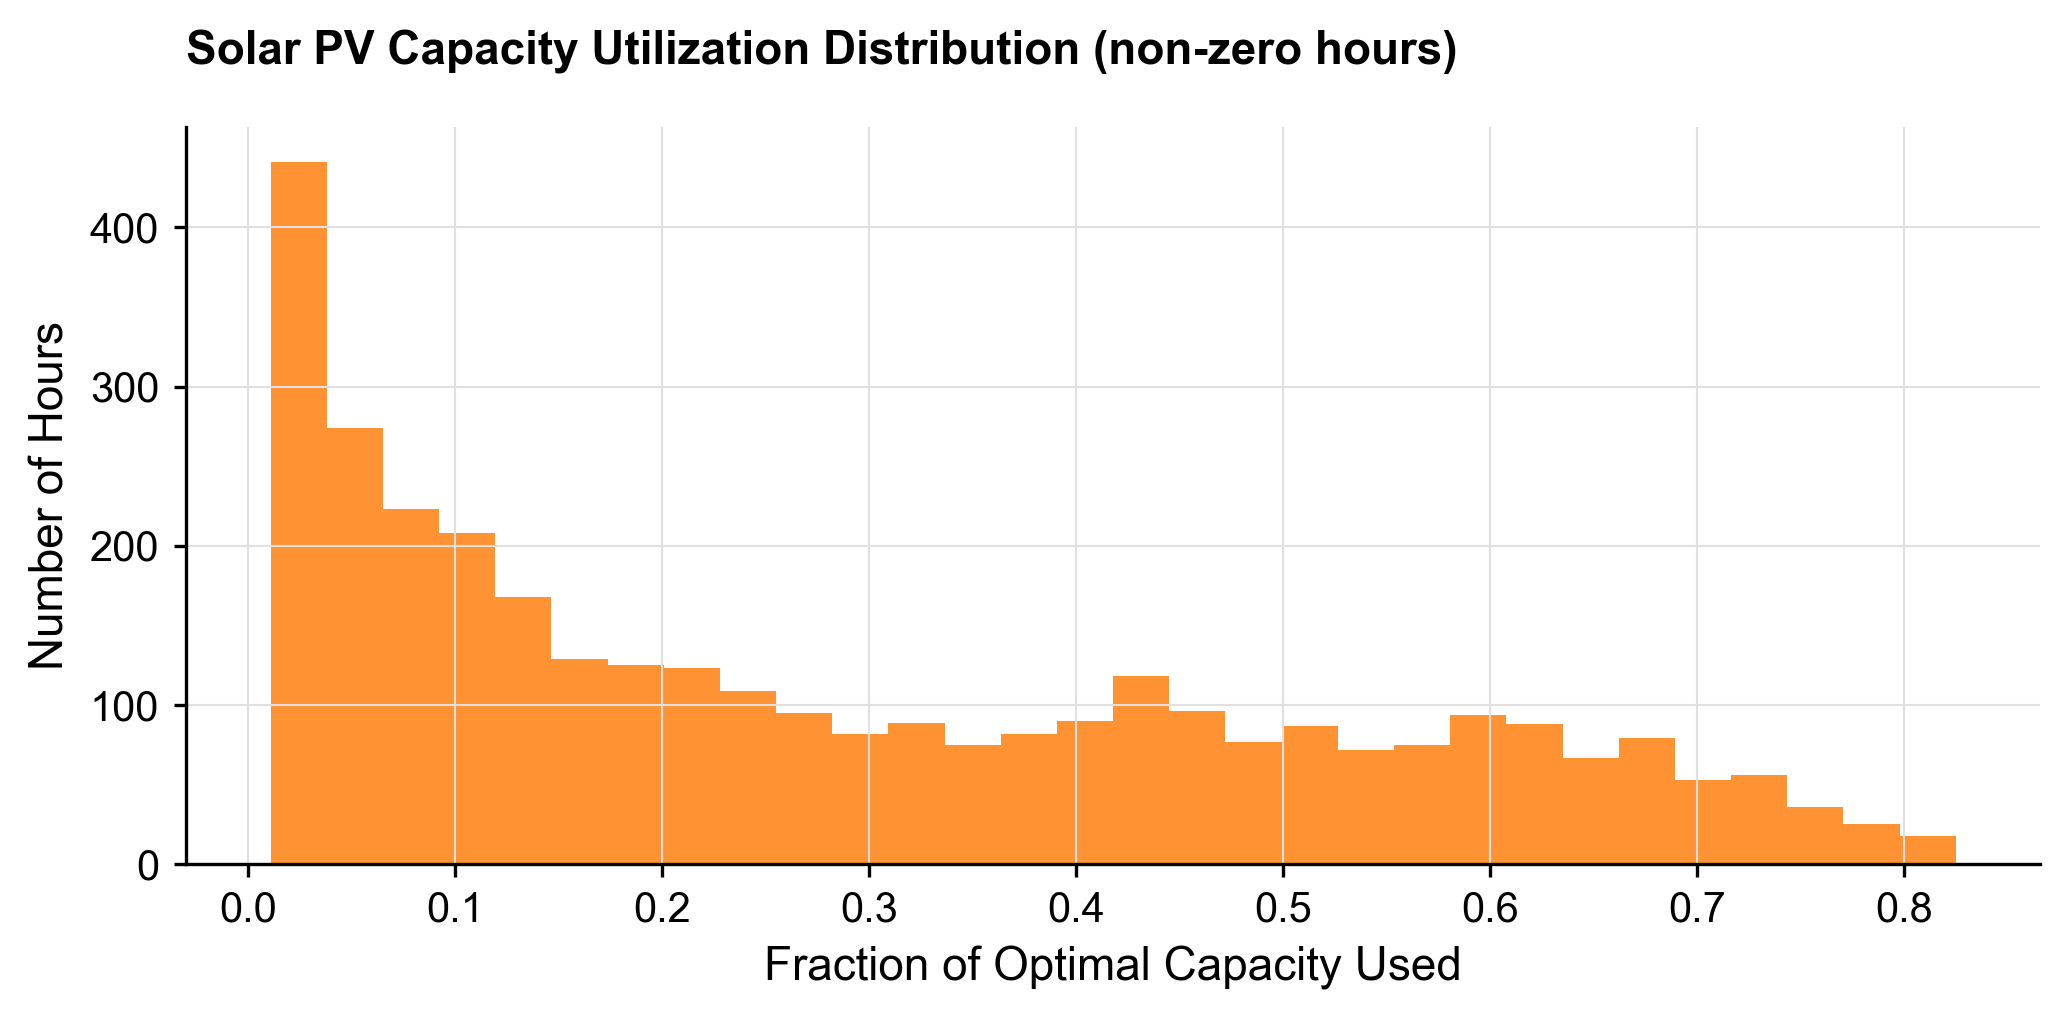

In [7]:
optimal_solar_mw = n.generators.at['Solar_PV', 'p_nom_opt']
solar_capex_annual = optimal_solar_mw * tech_param['solar_pv']['capital_cost']

solar_gen_mwh = n.generators_t.p['Solar_PV'].sum()
wind_gen_mwh = n.generators_t.p['Wind'].sum()
import_mwh = n.generators_t.p['Grid_Import'].sum()
export_mwh = -n.generators_t.p['Grid_Export'].sum()

print(f"Optimal Solar PV Capacity:      {optimal_solar_mw:,.2f} MW  (site limit: {tech_param['solar_pv']['p_nom_max']:.1f} MW)")
print(f"Solar Annualized CAPEX:         EUR {solar_capex_annual:,.2f} / year")
print("-" * 45)
print(f"Solar Production:               {solar_gen_mwh:,.2f} MWh")
print(f"Wind Production:                {wind_gen_mwh:,.2f} MWh")
print(f"Grid Import:                    {import_mwh:,.2f} MWh")
print(f"Grid Export:                    {export_mwh:,.2f} MWh")

# Plot capacity utilization: how often optimal solar capacity is actually near its own ceiling
fig, ax = plt.subplots()
utilization = n.generators_t.p['Solar_PV'] / optimal_solar_mw
ax.hist(utilization[utilization > 0.01], bins=30, color='#ff7f0e', alpha=0.85)
ax.set_xlabel('Fraction of Optimal Capacity Used')
ax.set_ylabel('Number of Hours')
ax.set_title('Solar PV Capacity Utilization Distribution (non-zero hours)', pad=15, loc='left', fontweight='bold')
plt.tight_layout()
plt.show()
